<a href="https://colab.research.google.com/github/Syoun68/Seoyoun_bigdata_computing/blob/main/%E1%84%8C%E1%85%AE%E1%86%BC%E1%84%80%E1%85%A1%E1%86%AB%E1%84%80%E1%85%A9%E1%84%89%E1%85%A1_%E1%84%91%E1%85%B3%E1%84%85%E1%85%A9%E1%84%80%E1%85%B3%E1%84%85%E1%85%A2%E1%84%86%E1%85%B5%E1%86%BC_%E1%84%80%E1%85%AA%E1%84%8C%E1%85%A6_20250583%EC%9D%B4%EC%84%9C%EC%9C%A4_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  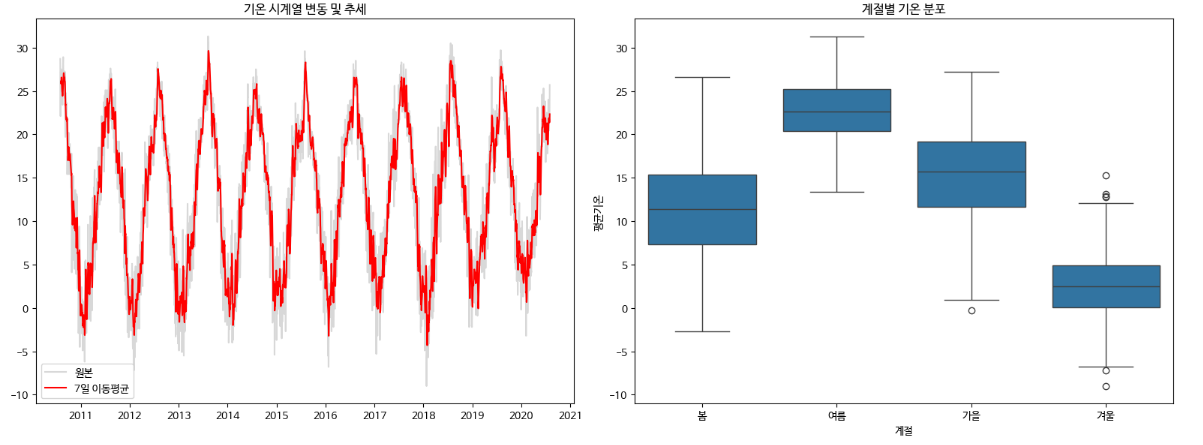

  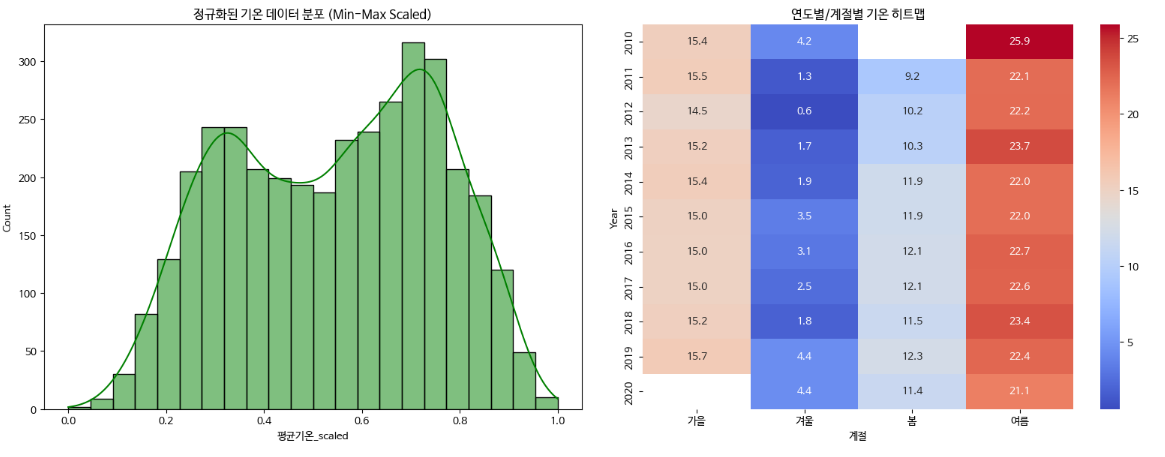



✅ 환경 설정 완료


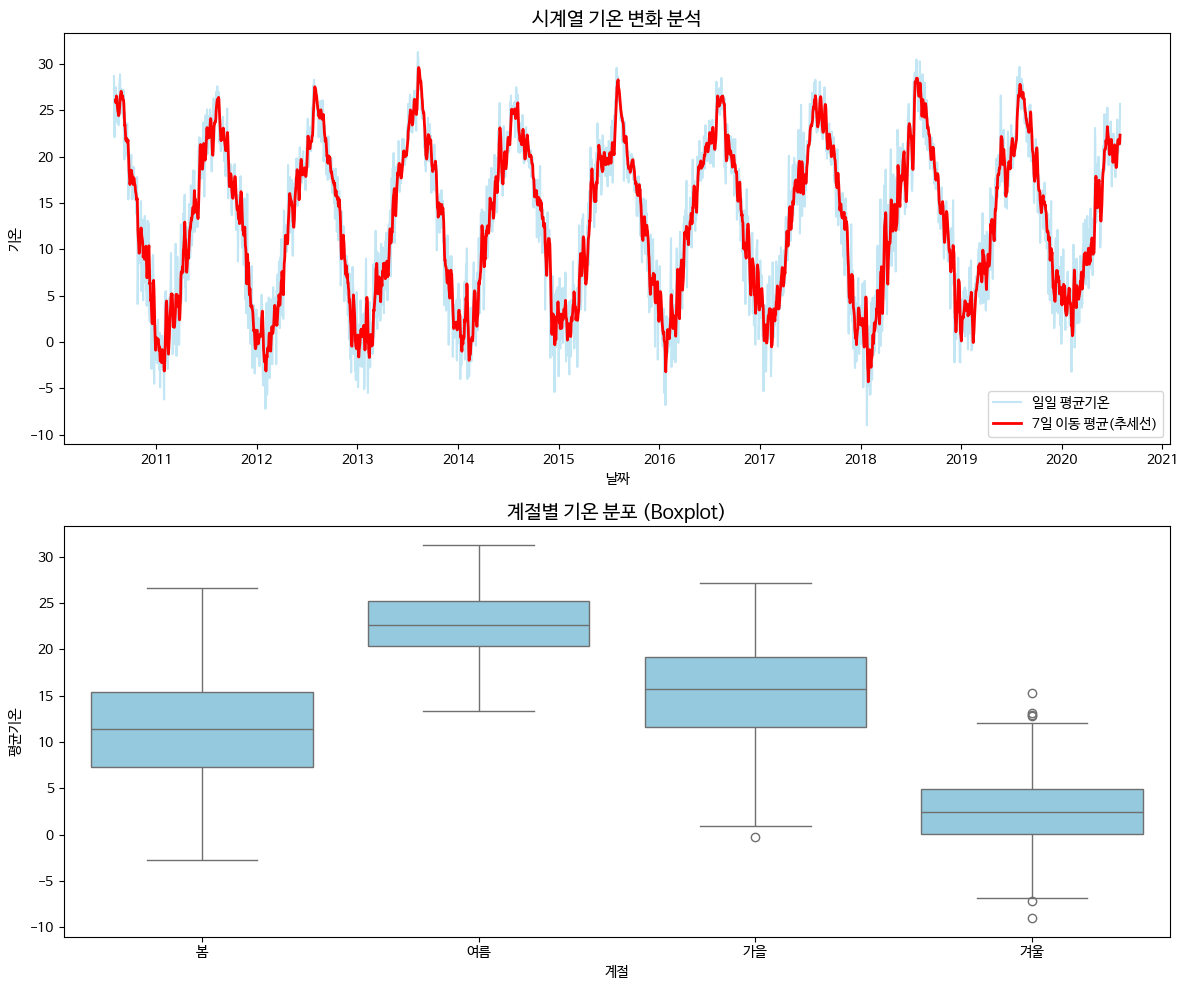

✅ 그래프 시각화 완료 (그래프 3 제외)
✅ 분석 결과 엑셀 저장 완료

 모든 분석 과정이 완료되었습니다.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup():
    warnings.filterwarnings('ignore')
    # 코랩 나눔폰트 경로 설정
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 환경별 기본 폰트 설정
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 완료")

# ---------------------------------------------------------
# 2. 데이터 처리 함수 (전처리, 정규화)
# ---------------------------------------------------------
def load_and_preprocess():
    # 데이터 로드
    try:
        df = pd.read_csv('weather.csv', encoding='utf-8')
    except:
        df = pd.read_csv('weather.csv', encoding='cp949')

    # 결측치 처리 (기온은 평균, 풍속은 0으로 채우는 전략)
    df['평균기온'] = df['평균기온'].fillna(df['평균기온'].mean())
    df['최대풍속'] = df['최대풍속'].fillna(0.0)
    df['평균풍속'] = df['평균풍속'].fillna(0.0)

    # 날짜 및 파생 변수 생성
    df['일시'] = pd.to_datetime(df['일시'])
    df['연도'] = df['일시'].dt.year
    df['월'] = df['일시'].dt.month

    def get_season(m):
        if 3 <= m <= 5: return '봄'
        elif 6 <= m <= 8: return '여름'
        elif 9 <= m <= 11: return '가을'
        else: return '겨울'
    df['계절'] = df['월'].apply(get_season)

    # 요구사항: 정규화 (Min-Max Scaling)
    target = df['평균기온']
    df['평균기온_정규화'] = (target - target.min()) / (target.max() - target.min())

    return df

# ---------------------------------------------------------
# 3. 시각화 함수 (그래프 2개 구성 - 보라색 통일)
# ---------------------------------------------------------
def draw_plots(df):
    # 시계열 인덱스 설정 및 7일 이동평균 계산
    df_plot = df.copy().set_index('일시')
    df_plot['7일이동평균'] = df_plot['평균기온'].rolling(window=7).mean()

    # 도화지 크기 설정 (2행 1열 구조)
    plt.figure(figsize=(12, 10))

    # [그래프 1] 상단: 시계열 기온 변화 및 추세선
    plt.subplot(2, 1, 1)
    plt.plot(df_plot.index, df_plot['평균기온'], label='일일 평균기온', color='skyblue', alpha=0.5)
    plt.plot(df_plot.index, df_plot['7일이동평균'], label='7일 이동 평균(추세선)', color='red', linewidth=2)
    plt.title('시계열 기온 변화 분석', fontsize=14)
    plt.xlabel('날짜')
    plt.ylabel('기온')
    plt.legend()

    # [그래프 2] 하단: 계절별 기온 분포 (보라색 박스플롯 하나만 배치)
    plt.subplot(2, 1, 2)
    sns.boxplot(x='계절', y='평균기온', data=df, order=['봄', '여름', '가을', '겨울'], color='skyblue')
    plt.title('계절별 기온 분포 (Boxplot)', fontsize=14)
    plt.xlabel('계절')
    plt.ylabel('평균기온')

    plt.tight_layout()
    plt.show()
    print("✅ 그래프 시각화 완료 (그래프 3 제외)")

# ---------------------------------------------------------
# 4. 데이터 재구조화 및 저장
# ---------------------------------------------------------
def save_results(df):
    # groupby 및 pivot_table 활용
    seasonal = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean()
    yearly = df.pivot_table(index='연도', values=['평균기온', '최대풍속'], aggfunc='mean')

    # 엑셀 저장 (3개 시트)
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='전처리데이터', index=False)
        seasonal.to_excel(writer, sheet_name='계절별통계')
        yearly.to_excel(writer, sheet_name='연도별피벗')
    print("✅ 분석 결과 엑셀 저장 완료")

# ---------------------------------------------------------
# 5. 메인 함수
# ---------------------------------------------------------
def main():
    setup()
    data = load_and_preprocess()
    draw_plots(data)
    save_results(data)
    print("\n 모든 분석 과정이 완료되었습니다.")

if __name__ == "__main__":
    main()

✅ 환경 설정 완료


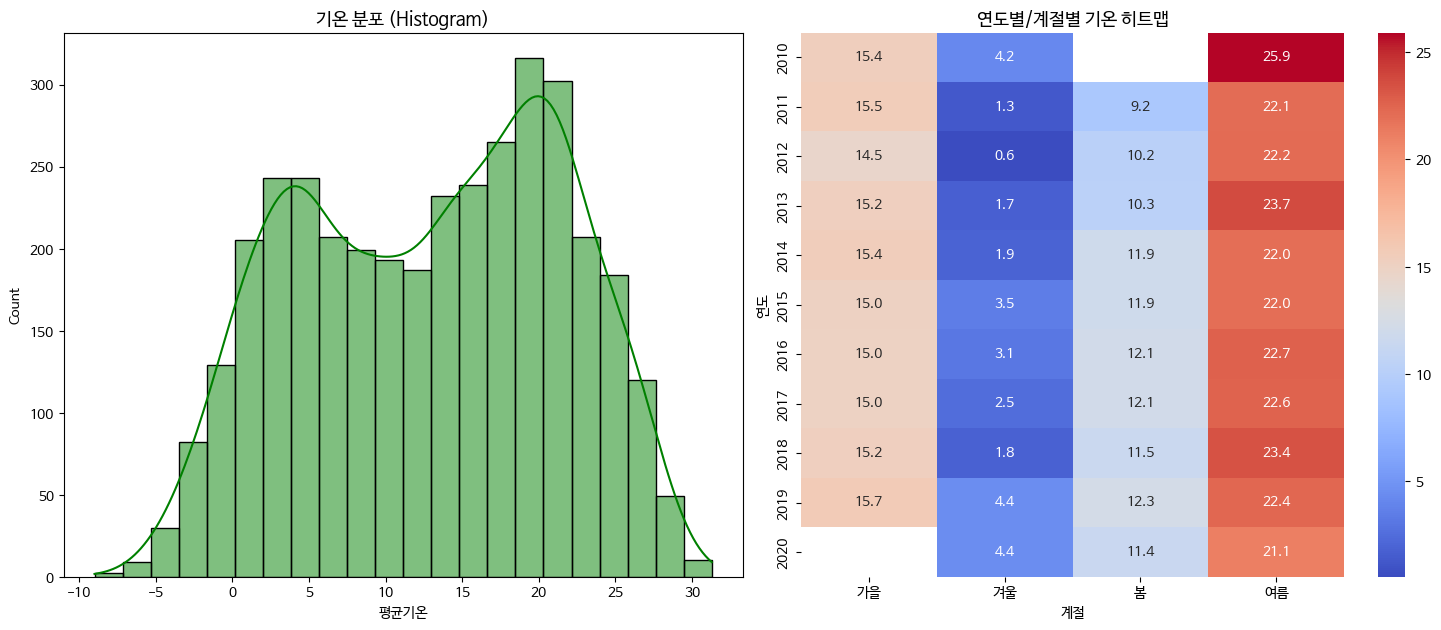

✅ 3종 그래프 시각화 완료 (풍속 상관관계 제외)
✅ 엑셀 파일 저장 완료

 모든 분석 파이프라인이 성공적으로 종료되었습니다!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정 (한글 폰트 및 설정)
# ---------------------------------------------------------
def setup():
    warnings.filterwarnings('ignore')
    # 코랩 나눔폰트 경로 설정
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 완료")

# ---------------------------------------------------------
# 2. 데이터 처리 함수 (전처리, 정규화)
# ---------------------------------------------------------
def load_and_preprocess():
    try:
        df = pd.read_csv('weather.csv', encoding='utf-8')
    except:
        df = pd.read_csv('weather.csv', encoding='cp949')

    # 결측치 처리 (기온은 평균, 풍속은 0.0으로 처리)
    df['평균기온'] = df['평균기온'].fillna(df['평균기온'].mean())
    df['최대풍속'] = df['최대풍속'].fillna(0.0)
    df['평균풍속'] = df['평균풍속'].fillna(0.0)

    # 날짜 및 계절 생성
    df['일시'] = pd.to_datetime(df['일시'])
    df['연도'] = df['일시'].dt.year
    df['월'] = df['일시'].dt.month

    def get_season(m):
        if 3 <= m <= 5: return '봄'
        elif 6 <= m <= 8: return '여름'
        elif 9 <= m <= 11: return '가을'
        else: return '겨울'
    df['계절'] = df['월'].apply(get_season)

    # 핵심요구사항: 정규화 (Min-Max Scaling)
    temp_col = df['평균기온']
    df['평균기온_정규화'] = (temp_col - temp_col.min()) / (temp_col.max() - temp_col.min())

    return df

# ---------------------------------------------------------
# 3. 시각화 함수 (3종 그래프 구성)
# ---------------------------------------------------------
def draw_plots(df):
    # 시계열 추세선 계산
    df_plot = df.copy().set_index('일시')
    df_plot['7일이동평균'] = df_plot['평균기온'].rolling(window=7).mean()

    # 도화지 설정
    plt.figure(figsize=(15, 12))


    # [2] 하단 왼쪽: 기온 분포 (Histogram)
    plt.subplot(2, 2, 3)
    sns.histplot(df['평균기온'], kde=True, color='green')
    plt.title('기온 분포 (Histogram)', fontsize=13)
    plt.xlabel('평균기온')

    # [3] 하단 오른쪽: 연도/계절별 기온 히트맵
    plt.subplot(2, 2, 4)

    # 피벗 테이블 생성 (연도 x 계절)
    heatmap_data = df.pivot_table(
        index='연도',
        columns='계절',
        values='평균기온',
        aggfunc='mean'
    )

    # 계절 순서 정렬
    heatmap_data = heatmap_data[['가을', '겨울', '봄', '여름']]

    # 히트맵 그리기
    sns.heatmap(
        heatmap_data,
        annot=True,       # 숫자 표시
        fmt=".1f",        # 소수점 1자리
        cmap="coolwarm"   # 색상
    )

    plt.title('연도별/계절별 기온 히트맵', fontsize=13)
    plt.xlabel('계절')
    plt.ylabel('연도')

    plt.tight_layout()
    plt.show()
    print("✅ 3종 그래프 시각화 완료 (풍속 상관관계 제외)")

# ---------------------------------------------------------
# 4. 데이터 재구조화 및 저장
# ---------------------------------------------------------
def save_results(df):
    # 핵심요구사항: groupby 및 pivot_table 활용
    seasonal = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean()
    yearly = df.pivot_table(index='연도', values=['평균기온', '최대풍속'], aggfunc='mean')

    # 엑셀 저장 (3개 시트)
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='전처리데이터', index=False)
        seasonal.to_excel(writer, sheet_name='계절별통계')
        yearly.to_excel(writer, sheet_name='연도별피벗')
    print("✅ 엑셀 파일 저장 완료")

# ---------------------------------------------------------
# 5. 메인 함수
# ---------------------------------------------------------
def main():
    setup()
    data = load_and_preprocess()
    draw_plots(data)
    save_results(data)
    print("\n 모든 분석 파이프라인이 성공적으로 종료되었습니다!")

if __name__ == "__main__":
    main()